In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [23]:
# Catalogo de productos usando tuplas
catalogo = (
    (1, "Laptop"),
    (2, "Mouse"),
    (3, "Teclado"),
    (4, "Monitor"),
    (5, "Audifonos"),
    (6, "Webcam")
)

# Precios usando diccionarios
precios = {
    1: 750.00,
    2: 15.00,
    3: 25.00,
    4: 180.00,
    5: 35.00,
    6: 45.00
}

# Stock usando diccionarios
stock = {
    1: 20,
    2: 50,
    3: 40,
    4: 25,
    5: 35,
    6: 30
}

# Lista donde se guardaran las ventas
ventas = []

In [24]:
def mostrar_catalogo():
    print("CATALOGO DE PRODUCTOS")
    print("---------------------")

    for producto_id, nombre in catalogo:
        print(
            producto_id,
            "-",
            nombre,
            "- Precio: $",
            precios[producto_id],
            "- Stock:",
            stock[producto_id]
        )

In [25]:
mostrar_catalogo()

CATALOGO DE PRODUCTOS
---------------------
1 - Laptop - Precio: $ 750.0 - Stock: 20
2 - Mouse - Precio: $ 15.0 - Stock: 50
3 - Teclado - Precio: $ 25.0 - Stock: 40
4 - Monitor - Precio: $ 180.0 - Stock: 25
5 - Audifonos - Precio: $ 35.0 - Stock: 35
6 - Webcam - Precio: $ 45.0 - Stock: 30


In [26]:
def guardar_log(mensaje):
    with open("log.txt", "a", encoding="utf-8") as archivo:
        archivo.write(mensaje + "\n")

In [27]:
def registrar_venta():
    try:
        producto_id = int(input("Ingrese el ID del producto: "))

        ids_catalogo = [producto[0] for producto in catalogo]

        if producto_id not in ids_catalogo:
            print("Error: el producto no existe.")
            guardar_log(
                "Intento fallido: producto ID " +
                str(producto_id) +
                " no existe."
            )
            return

        unidades = int(input("Ingrese la cantidad de unidades: "))

        if unidades <= 0:
            print("Error: la cantidad debe ser mayor a 0.")
            return

        if unidades > stock[producto_id]:
            print("Error: no hay suficiente stock.")
            return

        subtotal = precios[producto_id] * unidades

        # Descuento del 5% si compra 10 o mas unidades
        if unidades >= 10:
            descuento = subtotal * 0.05
        else:
            descuento = 0

        total = subtotal - descuento

        # Buscar el nombre del producto
        nombre = ""

        for id_producto, nombre_producto in catalogo:
            if id_producto == producto_id:
                nombre = nombre_producto
                break

        # Guardar venta en una lista
        venta = [
            producto_id,
            nombre,
            unidades,
            precios[producto_id],
            descuento,
            total
        ]

        ventas.append(venta)

        # Actualizar stock
        stock[producto_id] -= unidades

        print("\nVenta registrada correctamente.")
        print("Producto:", nombre)
        print("Unidades:", unidades)
        print("Precio unitario: $", precios[producto_id])
        print("Descuento: $", round(descuento, 2))
        print("Total: $", round(total, 2))

    except ValueError:
        print("Error: debe ingresar valores numericos.")

In [30]:
registrar_venta()

Ingrese el ID del producto: 99
Error: el producto no existe.


In [31]:
with open("log.txt", "r", encoding="utf-8") as archivo:
    print(archivo.read())

Intento fallido: producto ID 99 no existe.



In [32]:
print(ventas)

[[2, 'Mouse', 3, 15.0, 0, 45.0], [5, 'Audifonos', 10, 35.0, 17.5, 332.5]]


In [33]:
def crear_dataframe():
    columnas = [
        "producto_id",
        "producto",
        "unidades",
        "precio",
        "descuento",
        "total"
    ]

    df_ventas = pd.DataFrame(ventas, columns=columnas)

    return df_ventas

In [34]:
df_ventas = crear_dataframe()
df_ventas

,producto_id,producto,unidades,precio,descuento,total
0,2,Mouse,3,15.0,0.0,45.0
1,5,Audifonos,10,35.0,17.5,332.5


In [35]:
ventas_extra = [
    [1, "Laptop", 1, 750.0, 0.0, 750.0],
    [2, "Mouse", 5, 15.0, 0.0, 75.0],
    [3, "Teclado", 4, 25.0, 0.0, 100.0],
    [4, "Monitor", 2, 180.0, 0.0, 360.0],
    [6, "Webcam", 3, 45.0, 0.0, 135.0],
    [3, "Teclado", 10, 25.0, 12.5, 237.5],
    [2, "Mouse", 12, 15.0, 9.0, 171.0],
    [4, "Monitor", 1, 180.0, 0.0, 180.0]
]

for venta in ventas_extra:
    ventas.append(venta)

print("Total de ventas registradas:", len(ventas))

Total de ventas registradas: 10


In [36]:
df_ventas = crear_dataframe()
df_ventas

,producto_id,producto,unidades,precio,descuento,total
0,2,Mouse,3,15.0,0.0,45.0
1,5,Audifonos,10,35.0,17.5,332.5
2,1,Laptop,1,750.0,0.0,750.0
3,2,Mouse,5,15.0,0.0,75.0
4,3,Teclado,4,25.0,0.0,100.0
5,4,Monitor,2,180.0,0.0,360.0
6,6,Webcam,3,45.0,0.0,135.0
7,3,Teclado,10,25.0,12.5,237.5
8,2,Mouse,12,15.0,9.0,171.0
9,4,Monitor,1,180.0,0.0,180.0


In [37]:
df_ventas.to_csv("ventas.csv", index=False)

print("ventas.csv generado correctamente.")

ventas.csv generado correctamente.


In [38]:
# Ingresos por producto usando pandas
ingresos_por_producto = df_ventas.groupby("producto")["total"].sum()

print("Ingresos por producto:")
print(ingresos_por_producto)

Ingresos por producto:
producto
Audifonos    332.5
Laptop       750.0
Monitor      540.0
Mouse        291.0
Teclado      337.5
Webcam       135.0
Name: total, dtype: float64


In [39]:
# Convertir los totales a un arreglo de NumPy
totales = df_ventas["total"].to_numpy()

promedio_ventas = np.mean(totales)
desviacion_ventas = np.std(totales)
suma_ventas = np.sum(totales)

print("Promedio de ventas: $", round(promedio_ventas, 2))
print("Desviacion estandar: $", round(desviacion_ventas, 2))
print("Suma total de ventas: $", round(suma_ventas, 2))

Promedio de ventas: $ 238.6
Desviacion estandar: $ 196.79
Suma total de ventas: $ 2386.0


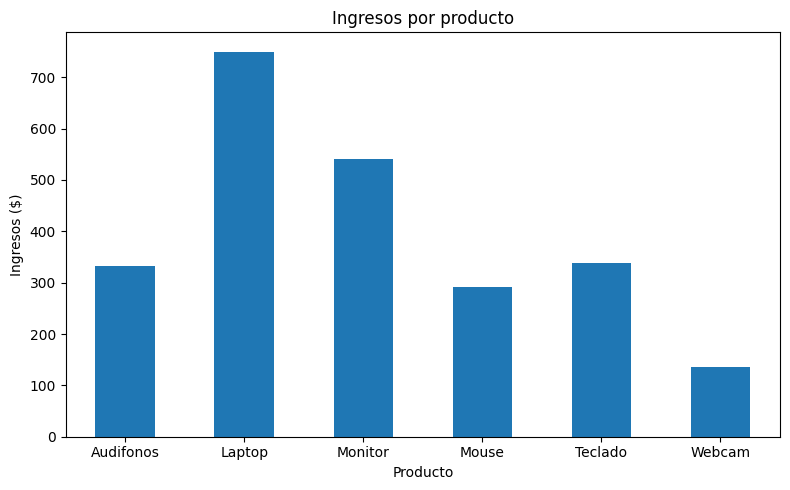

In [40]:
# Grafica de ingresos por producto

plt.figure(figsize=(8, 5))

ingresos_por_producto.plot(kind="bar")

plt.title("Ingresos por producto")
plt.xlabel("Producto")
plt.ylabel("Ingresos ($)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [42]:
def exportar_grafico():
    ingresos = df_ventas.groupby("producto")["total"].sum()

    plt.figure(figsize=(8, 5))
    ingresos.plot(kind="bar")

    plt.title("Ingresos por producto")
    plt.xlabel("Producto")
    plt.ylabel("Ingresos ($)")
    plt.xticks(rotation=0)
    plt.tight_layout()

    plt.savefig("ingresos.png")
    plt.close()

    print("Grafico exportado correctamente como ingresos.png")

In [43]:
exportar_grafico()

Grafico exportado correctamente como ingresos.png


In [44]:
def menu():
    while True:
        print("\n===== MINITIENDA =====")
        print("1. Mostrar catalogo")
        print("2. Registrar venta")
        print("3. Mostrar ventas")
        print("4. Mostrar metricas")
        print("5. Mostrar grafico")
        print("6. Exportar grafico a PNG")
        print("7. Salir")

        try:
            opcion = int(input("Seleccione una opcion: "))

        except ValueError:
            print("Error: ingrese un numero valido.")
            continue

        if opcion == 1:
            mostrar_catalogo()

        elif opcion == 2:
            registrar_venta()

        elif opcion == 3:
            df_actual = crear_dataframe()
            print(df_actual)

        elif opcion == 4:
            df_actual = crear_dataframe()

            if len(df_actual) == 0:
                print("No existen ventas registradas.")
                continue

            totales = df_actual["total"].to_numpy()

            print("Promedio: $", round(np.mean(totales), 2))
            print("Desviacion estandar: $", round(np.std(totales), 2))
            print("Total: $", round(np.sum(totales), 2))

        elif opcion == 5:
            df_actual = crear_dataframe()

            if len(df_actual) == 0:
                print("No existen ventas para graficar.")
                continue

            ingresos = df_actual.groupby("producto")["total"].sum()

            plt.figure(figsize=(8, 5))
            ingresos.plot(kind="bar")
            plt.title("Ingresos por producto")
            plt.xlabel("Producto")
            plt.ylabel("Ingresos ($)")
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()

        elif opcion == 6:
            exportar_grafico()

        elif opcion == 7:
            print("Programa finalizado.")
            break

        else:
            print("Opcion no valida.")

In [48]:
menu()


===== MINITIENDA =====
1. Mostrar catalogo
2. Registrar venta
3. Mostrar ventas
4. Mostrar metricas
5. Mostrar grafico
6. Exportar grafico a PNG
7. Salir


KeyboardInterrupt: Interrupted by user

In [49]:
def leer_ventas_csv():
    try:
        datos = pd.read_csv("ventas.csv")

    except FileNotFoundError:
        print("Error: el archivo ventas.csv no existe.")

    else:
        print("Archivo ventas.csv leido correctamente.")
        print(datos.head())

    finally:
        print("Proceso de lectura finalizado.")

In [50]:
leer_ventas_csv()

Archivo ventas.csv leido correctamente.
   producto_id   producto  unidades  precio  descuento  total
0            2      Mouse         3    15.0        0.0   45.0
1            5  Audifonos        10    35.0       17.5  332.5
2            1     Laptop         1   750.0        0.0  750.0
3            2      Mouse         5    15.0        0.0   75.0
4            3    Teclado         4    25.0        0.0  100.0
Proceso de lectura finalizado.


In [51]:
def promedio_por_unidad(total, unidades):
    try:
        resultado = total / unidades

    except ZeroDivisionError:
        print("Error: no se puede dividir para cero.")
        return 0

    else:
        return resultado

    finally:
        print("Calculo finalizado.")

In [52]:
promedio_por_unidad(100, 0)

Error: no se puede dividir para cero.
Calculo finalizado.


0

## Respuestas

### ¿Que parte la hizo Pandas? ¿Que parte NumPy?

Pandas se utilizo para crear el DataFrame de las ventas, agrupar los datos por producto mediante groupby y guardar y leer la informacion en el archivo ventas.csv.

NumPy se utilizo para realizar los calculos numericos de las ventas, como el promedio con np.mean(), la desviacion estandar con np.std() y la suma total con np.sum().

### ¿Donde usaste try/except y por que?

Se utilizo try/except para controlar errores durante la ejecucion del programa. Se uso al ingresar datos numericos, al intentar leer el archivo ventas.csv y al controlar una division por cero. Esto permite que el programa muestre un mensaje de error en lugar de detenerse.

### ¿Que estructuras son tuplas, listas y diccionarios en el codigo?

La variable catalogo es una tupla que contiene los productos de la tienda. La variable ventas es una lista donde se almacenan las ventas registradas. Las variables precios y stock son diccionarios que relacionan el ID de cada producto con su precio y cantidad disponible.